# Hour-of-day + Volume-spike experiments

**Date:** 2026-04-20  
**Inspired by:** Sarainmaa 2024 (S&P 500 swing trading with random forest + TA) — paper added seasonality attributes and volume change as features. Pan 2004 also flagged physical cycles (hour-of-day, day-of-week).

## Goals

1. **Hour-of-day analysis** — for each symbol in the active rotation, does P&L concentrate in specific UTC hours? If yes, a session filter could lift PF further.
2. **Volume-spike confirmation** — if entries are filtered to bars where volume > 1.5× 20-bar avg, does PF improve? Reduces low-conviction noise trades.

## Setup

Reuses same backtest engine + data cache used by `/tmp/intense_bt.py`. All 9 active symbols, deployed configs (BTC-confirm on 6).

In [1]:
import os, sys, json, time
from dataclasses import dataclass, replace
from collections import defaultdict

sys.path.insert(0, '/Users/lucaneto/Trading/shared')
sys.path.insert(0, '/Users/lucaneto/Trading/swing-trading-bot')

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')
plt.rcParams['figure.facecolor'] = '#0b0f0e'
plt.rcParams['axes.facecolor'] = '#0b0f0e'
plt.rcParams['axes.edgecolor'] = '#1b2420'
plt.rcParams['axes.labelcolor'] = '#e6eeea'
plt.rcParams['xtick.color'] = '#7a8480'
plt.rcParams['ytick.color'] = '#7a8480'
plt.rcParams['text.color'] = '#e6eeea'
plt.rcParams['axes.titlecolor'] = '#e6eeea'
plt.rcParams['grid.color'] = '#1b2420'

SYMBOLS = ['BTC', 'HYPE', 'ZEC', 'XRP', 'kPEPE', 'FARTCOIN', 'LIT', 'ENA', 'SOL']
HL_CAP = {'BTC': 40, 'HYPE': 10, 'ZEC': 10, 'XRP': 20, 'kPEPE': 10,
          'FARTCOIN': 10, 'LIT': 5, 'ENA': 10, 'SOL': 20}
HL_API = 'https://api.hyperliquid.xyz/info'
COMMISSION = 0.00006
CACHE_DIR = '/Users/lucaneto/Trading/commodities-bot/research/notebooks/data/whale_swing_cache'
DEPLOY_DIR = '/Users/lucaneto/Trading/swing-trading-bot/config/deployed'

/Users/lucaneto/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
# Fetch + feature helpers (same logic as intense_bt.py)
def fetch_hl(symbol, interval, bars=10000):
    cache_file = os.path.join(CACHE_DIR, f'{symbol.replace(":", "_")}_{interval}.csv')
    if os.path.exists(cache_file):
        age = time.time() - os.path.getmtime(cache_file)
        if age < 3600 * 4:
            return pd.read_csv(cache_file, parse_dates=['timestamp'])
    ms = {'5m': 300_000, '1h': 3_600_000, '4h': 14_400_000}[interval]
    end = int(time.time() * 1000)
    all_data, remaining, CHUNK = [], bars, 4500
    while remaining > 0:
        take = min(CHUNK, remaining)
        start = end - ms * take
        r = requests.post(HL_API, json={'type': 'candleSnapshot',
            'req': {'coin': symbol, 'interval': interval, 'startTime': start, 'endTime': end}}, timeout=30)
        data = r.json() or []
        if not data: break
        all_data = data + all_data
        end = int(data[0]['t']) - ms
        remaining -= len(data)
        if len(data) < take * 0.5: break
        time.sleep(0.3)
    seen = {int(c['t']): c for c in all_data}
    sd = sorted(seen.values(), key=lambda c: int(c['t']))
    df = pd.DataFrame([{
        'timestamp': pd.to_datetime(int(c['t']), unit='ms', utc=True),
        'open': float(c['o']), 'high': float(c['h']),
        'low': float(c['l']), 'close': float(c['c']),
        'volume': float(c['v']),
    } for c in sd])
    df.to_csv(cache_file, index=False)
    return df

def add_features(df):
    df = df.copy()
    c = df['close']; h = df['high']; l = df['low']; v = df['volume']
    df['ema_21'] = c.ewm(span=21, adjust=False).mean()
    df['ema_50'] = c.ewm(span=50, adjust=False).mean()
    df['ema_200'] = c.ewm(span=200, adjust=False).mean()
    df['ema_50_slope'] = (df['ema_50'] - df['ema_50'].shift(20)) / df['ema_50'].shift(20)
    delta = c.diff()
    gain = delta.where(delta > 0, 0.0).ewm(alpha=1/14, adjust=False).mean()
    loss = (-delta.where(delta < 0, 0.0)).ewm(alpha=1/14, adjust=False).mean()
    rs = gain / loss.replace(0, np.nan)
    df['rsi'] = 100 - 100 / (1 + rs)
    tr = pd.concat([h-l, (h-c.shift(1)).abs(), (l-c.shift(1)).abs()], axis=1).max(axis=1)
    df['atr'] = tr.ewm(alpha=1/14, adjust=False).mean()
    df['bb_mid'] = c.rolling(20).mean()
    bb_std = c.rolling(20).std()
    df['bb_upper'] = df['bb_mid'] + 2 * bb_std
    df['bb_lower'] = df['bb_mid'] - 2 * bb_std
    # NEW FEATURE: volume-ratio to 20-bar rolling mean
    df['vol_ma20'] = v.rolling(20).mean()
    df['vol_ratio'] = v / df['vol_ma20']
    return df

from core.features import trend_lookup_1h, structure_lookup_1h

@dataclass
class Cfg:
    trend_filter: str; entry_type: str
    rsi_oversold: float; rsi_overbought: float
    sl_atr: float; tp1_atr: float; tp1_pct: float; trail_atr: float
    max_hold_bars: int; direction: str; use_1h_filter: bool
    trend_filter_1h: str = 'both_agree'
    require_4h_agreement: bool = False
    require_btc_1h_confirm: bool = False
    tp2_atr: float = 0.0; tp2_pct: float = 0.0
    tp3_atr: float = 0.0; tp3_pct: float = 0.0

def build_btc_confirm(df5, df1h_btc):
    btc = df1h_btc.copy()
    btc['ret'] = np.log(btc['close']).diff()
    btc_ts = btc['timestamp'].values; btc_ret = btc['ret'].values
    t5 = df5['timestamp'].values
    out = np.zeros(len(t5), dtype=np.int8)
    j = 0
    for i in range(len(t5)):
        while j + 1 < len(btc_ts) and btc_ts[j + 1] <= t5[i]: j += 1
        r = btc_ret[j] if j < len(btc_ret) else np.nan
        if np.isnan(r) or r == 0: out[i] = 0
        elif r > 0: out[i] = 1
        else: out[i] = -1
    return out

def precompute(df5, df1h, df4h, btc_confirm):
    a = {col: df5[col].to_numpy() for col in
         ['open','high','low','close','atr','rsi','ema_21','ema_50','ema_200',
          'ema_50_slope','bb_lower','bb_upper','vol_ratio']}
    up_e, dn_e = trend_lookup_1h(df5, df1h)
    up_s, dn_s = structure_lookup_1h(df5, df1h)
    up_4h, dn_4h = structure_lookup_1h(df5, df4h, pivot_bars=3)
    ts = pd.to_datetime(df5['timestamp'])
    a.update({'up_1h': up_e, 'dn_1h': dn_e, 'up_struct': up_s, 'dn_struct': dn_s,
              'up_4h': up_4h, 'dn_4h': dn_4h, 'btc_dir': btc_confirm,
              'hour': ts.dt.hour.to_numpy(), 'dow': ts.dt.weekday.to_numpy(),
              'timestamp': df5['timestamp'].values})
    return a

print('helpers loaded')

helpers loaded


In [3]:
# Backtest engine — returns trades list with hour/vol_ratio/BTC-regime per trade
def backtest(arr, cfg, leverage, require_btc_confirm=False, min_vol_ratio=0.0):
    """Returns list of trade dicts: {pnl, side, reason, hour, dow, vol_ratio, btc_dir}."""
    n = len(arr['close'])
    close = arr['close']; high = arr['high']; low = arr['low']
    rsi = arr['rsi']; atr = arr['atr']
    e21 = arr['ema_21']; e50 = arr['ema_50']; e200 = arr['ema_200']; slope = arr['ema_50_slope']
    bbl = arr['bb_lower']; bbu = arr['bb_upper']
    vr = arr['vol_ratio']
    btc_dir = arr['btc_dir']
    hour = arr['hour']; dow = arr['dow']

    if cfg.trend_filter_1h == 'structure':
        up_1h = arr['up_struct']; dn_1h = arr['dn_struct']
    elif cfg.trend_filter_1h == 'both_agree':
        up_1h = arr['up_1h'] & arr['up_struct']; dn_1h = arr['dn_1h'] & arr['dn_struct']
    else:
        up_1h = arr['up_1h']; dn_1h = arr['dn_1h']

    trades = []
    position = None
    tp1_hit = tp2_hit = tp3_hit = False

    for i in range(52, n):
        a_i = atr[i]; r = rsi[i]
        if a_i <= 0 or a_i != a_i or r != r: continue
        r_prev = rsi[i-1]
        price = close[i]; hi = high[i]; lo = low[i]

        if position is not None:
            side = position['side']; entry = position['entry']
            trl = position['trail_offset']
            if trl > 0:
                if side == 'long':
                    if hi > position['best']: position['best'] = hi
                    if not position['trail_active'] and hi >= entry + trl: position['trail_active'] = True
                    if position['trail_active']:
                        ns = position['best'] - trl
                        if ns > position['sl']: position['sl'] = ns
                else:
                    if lo < position['best']: position['best'] = lo
                    if not position['trail_active'] and lo <= entry - trl: position['trail_active'] = True
                    if position['trail_active']:
                        ns = position['best'] + trl
                        if ns < position['sl']: position['sl'] = ns

            if not tp1_hit and position['tp1'] is not None:
                tp1 = position['tp1']
                if (side == 'long' and hi >= tp1) or (side == 'short' and lo <= tp1):
                    tp1_hit = True; pct = cfg.tp1_pct
                    pnl_p = ((tp1-entry) if side == 'long' else (entry-tp1)) * position['size'] * pct
                    pnl_p -= position['notional'] * pct * COMMISSION * 2
                    trades.append({'pnl': pnl_p, 'side': side, 'reason': 'tp1',
                                   'hour': position['hour'], 'dow': position['dow'],
                                   'vol_ratio': position['vol_ratio'], 'btc_dir': position['btc_dir']})
                    position['size'] *= (1-pct); position['notional'] *= (1-pct); position['sl'] = entry
            if tp1_hit and not tp2_hit and position.get('tp2') is not None:
                tp2 = position['tp2']
                if (side == 'long' and hi >= tp2) or (side == 'short' and lo <= tp2):
                    tp2_hit = True; pct = cfg.tp2_pct
                    pnl_p = ((tp2-entry) if side == 'long' else (entry-tp2)) * position['size'] * pct
                    pnl_p -= position['notional'] * pct * COMMISSION * 2
                    trades.append({'pnl': pnl_p, 'side': side, 'reason': 'tp2',
                                   'hour': position['hour'], 'dow': position['dow'],
                                   'vol_ratio': position['vol_ratio'], 'btc_dir': position['btc_dir']})
                    position['size'] *= (1-pct); position['notional'] *= (1-pct)
            if tp2_hit and not tp3_hit and position.get('tp3') is not None:
                tp3 = position['tp3']
                if (side == 'long' and hi >= tp3) or (side == 'short' and lo <= tp3):
                    tp3_hit = True; pct = cfg.tp3_pct
                    pnl_p = ((tp3-entry) if side == 'long' else (entry-tp3)) * position['size'] * pct
                    pnl_p -= position['notional'] * pct * COMMISSION * 2
                    trades.append({'pnl': pnl_p, 'side': side, 'reason': 'tp3',
                                   'hour': position['hour'], 'dow': position['dow'],
                                   'vol_ratio': position['vol_ratio'], 'btc_dir': position['btc_dir']})
                    position['size'] *= (1-pct); position['notional'] *= (1-pct)

            sl_hit = (lo <= position['sl']) if side == 'long' else (hi >= position['sl'])
            max_hold_hit = (i - position['entry_bar']) >= cfg.max_hold_bars
            if sl_hit or max_hold_hit:
                ep = position['sl'] if sl_hit else price
                pnl = ((ep-entry) if side == 'long' else (entry-ep)) * position['size']
                pnl -= position['notional'] * COMMISSION * 2
                trades.append({'pnl': pnl, 'side': side, 'reason': 'sl' if sl_hit else 'max_hold',
                               'hour': position['hour'], 'dow': position['dow'],
                               'vol_ratio': position['vol_ratio'], 'btc_dir': position['btc_dir']})
                position = None; tp1_hit = tp2_hit = tp3_hit = False
                continue

        if position is not None: continue

        tf = cfg.trend_filter
        if tf == 'ema_cross': up_ok = e21[i] > e50[i]; dn_ok = e21[i] < e50[i]
        elif tf == 'ema_slope': up_ok = slope[i] > 0; dn_ok = slope[i] < 0
        elif tf == 'ema200':
            up_ok = price > e200[i] if e200[i] > 0 else True
            dn_ok = price < e200[i] if e200[i] > 0 else True
        else: up_ok = True; dn_ok = True

        if cfg.use_1h_filter:
            if not up_1h[i]: up_ok = False
            if not dn_1h[i]: dn_ok = False
        if cfg.require_4h_agreement:
            if not arr['up_4h'][i]: up_ok = False
            if not arr['dn_4h'][i]: dn_ok = False
        d = cfg.direction
        if d == 'long_only': dn_ok = False
        elif d == 'short_only': up_ok = False

        long_trig = short_trig = False
        et = cfg.entry_type
        if et == 'rsi_bounce':
            long_trig = up_ok and r_prev < cfg.rsi_oversold and r >= cfg.rsi_oversold
            short_trig = dn_ok and r_prev > cfg.rsi_overbought and r <= cfg.rsi_overbought
        elif et == 'bb_touch':
            long_trig = up_ok and low[i-1] <= bbl[i] and price > high[i-1]
            short_trig = dn_ok and high[i-1] >= bbu[i] and price < low[i-1]
        elif et == 'ema_bounce':
            long_trig = up_ok and low[i-1] <= e21[i] and price > e21[i] and r_prev < 45
            short_trig = dn_ok and high[i-1] >= e21[i] and price < e21[i] and r_prev > 55
        elif et == 'swing_pivot':
            if i >= 55:
                if up_ok and low[i-3] < low[i-4] and low[i-3] < low[i-2] and price > high[i-1]: long_trig = True
                if dn_ok and high[i-3] > high[i-4] and high[i-3] > high[i-2] and price < low[i-1]: short_trig = True

        if require_btc_confirm:
            if long_trig and btc_dir[i] != 1: long_trig = False
            if short_trig and btc_dir[i] != -1: short_trig = False

        # Volume filter — skip low-conviction bars
        if min_vol_ratio > 0 and (np.isnan(vr[i]) or vr[i] < min_vol_ratio):
            long_trig = short_trig = False

        if long_trig or short_trig:
            side = 'long' if long_trig else 'short'
            margin = 10000 * 0.15; notional = margin * leverage; size = notional / price
            sl = price - a_i * cfg.sl_atr if side == 'long' else price + a_i * cfg.sl_atr
            tp1 = price + a_i * cfg.tp1_atr if cfg.tp1_atr > 0 and side == 'long' else (price - a_i * cfg.tp1_atr if cfg.tp1_atr > 0 else None)
            tp2 = price + a_i * cfg.tp2_atr if cfg.tp2_atr > 0 and side == 'long' else (price - a_i * cfg.tp2_atr if cfg.tp2_atr > 0 else None)
            tp3 = price + a_i * cfg.tp3_atr if cfg.tp3_atr > 0 and side == 'long' else (price - a_i * cfg.tp3_atr if cfg.tp3_atr > 0 else None)
            trail = a_i * cfg.trail_atr if cfg.trail_atr > 0 else 0.0
            position = dict(entry=price, side=side, size=size, notional=notional,
                           sl=sl, tp1=tp1, tp2=tp2, tp3=tp3,
                           trail_offset=trail, trail_active=False, best=price, entry_bar=i,
                           hour=int(hour[i]), dow=int(dow[i]),
                           vol_ratio=float(vr[i]) if not np.isnan(vr[i]) else 0.0,
                           btc_dir=int(btc_dir[i]))
            tp1_hit = tp2_hit = tp3_hit = False
    return trades

print('backtest fn ready')

backtest fn ready


In [4]:
# Fetch data for all symbols and run baseline deployed backtest
print('Fetching BTC 1h...')
df1h_btc = fetch_hl('BTC', '1h', 2000)

all_trades = []   # [{symbol, pnl, hour, dow, vol_ratio, ...}, ...]
for sym in SYMBOLS:
    fn = f'whale_{sym.replace(":","_")}.json'
    d = json.load(open(os.path.join(DEPLOY_DIR, fn)))
    cfg_d = Cfg(
        trend_filter=d['trend_filter'], entry_type=d['entry_type'],
        rsi_oversold=d['rsi_oversold'], rsi_overbought=d['rsi_overbought'],
        sl_atr=d['sl_atr'], tp1_atr=d['tp1_atr'], tp1_pct=d['tp1_pct'],
        trail_atr=d['trail_atr'], max_hold_bars=d['max_hold_bars'],
        direction=d['direction'], use_1h_filter=d['use_1h_filter'],
        trend_filter_1h=d.get('trend_filter_1h', 'ema_cross'),
        require_4h_agreement=bool(d.get('require_4h_agreement', False)),
        require_btc_1h_confirm=bool(d.get('require_btc_1h_confirm', False)),
        tp2_atr=float(d.get('tp2_atr', 0.0)), tp2_pct=float(d.get('tp2_pct', 0.0)),
        tp3_atr=float(d.get('tp3_atr', 0.0)), tp3_pct=float(d.get('tp3_pct', 0.0)),
    )
    df5 = add_features(fetch_hl(sym, '5m', 10000))
    df1h = add_features(fetch_hl(sym, '1h', 2000))
    df4h = add_features(fetch_hl(sym, '4h', 1000))
    if len(df5) < 250: continue
    arr = precompute(df5, df1h, df4h, build_btc_confirm(df5, df1h_btc))
    eff_lev = HL_CAP[sym] * 0.15
    trades = backtest(arr, cfg_d, leverage=eff_lev,
                      require_btc_confirm=cfg_d.require_btc_1h_confirm)
    for t in trades: t['symbol'] = sym
    all_trades.extend(trades)
    print(f'  {sym:<10} {len(trades)} trades, total P&L ${sum(t["pnl"] for t in trades):+.0f}')

trades_df = pd.DataFrame(all_trades)
print(f'\nTotal trades: {len(trades_df)}')
print(f'Total P&L: ${trades_df["pnl"].sum():+.2f}')

Fetching BTC 1h...
  BTC        108 trades, total P&L $+288
  HYPE       28 trades, total P&L $-14
  ZEC        46 trades, total P&L $+444
  XRP        31 trades, total P&L $+219
  kPEPE      29 trades, total P&L $+84
  FARTCOIN   68 trades, total P&L $+504
  LIT        133 trades, total P&L $+158
  ENA        28 trades, total P&L $-8
  SOL        17 trades, total P&L $+61

Total trades: 488
Total P&L: $+1736.97


## Experiment 1 — Hour-of-day P&L distribution

In [5]:
# Aggregate P&L by UTC hour across all symbols
by_hour = trades_df.groupby('hour').agg(n=('pnl', 'count'), pnl=('pnl', 'sum'),
                                         win_rate=('pnl', lambda x: (x>0).mean()*100),
                                         gross_win=('pnl', lambda x: x[x>0].sum()),
                                         gross_loss=('pnl', lambda x: -x[x<0].sum())).reset_index()
by_hour['pf'] = by_hour.apply(lambda r: r['gross_win']/r['gross_loss'] if r['gross_loss']>0 else np.nan, axis=1)
by_hour = by_hour.set_index('hour').reindex(range(24), fill_value=0).reset_index()
by_hour.round(2)

,hour,n,pnl,win_rate,gross_win,gross_loss,pf
0,0,19,61.02,84.21,96.34,35.32,2.73
1,1,12,34.26,66.67,84.66,50.40,1.68
2,2,15,248.45,73.33,314.98,66.53,4.73
3,3,10,-50.09,40.00,25.57,75.66,0.34
4,4,22,97.46,72.73,138.40,40.94,3.38
5,5,17,-0.61,70.59,64.95,65.56,0.99
6,6,26,101.45,84.62,148.45,47.00,3.16
7,7,26,105.37,84.62,150.22,44.85,3.35
8,8,23,44.80,69.57,114.37,69.57,1.64
9,9,25,-38.42,68.00,88.83,127.25,0.70


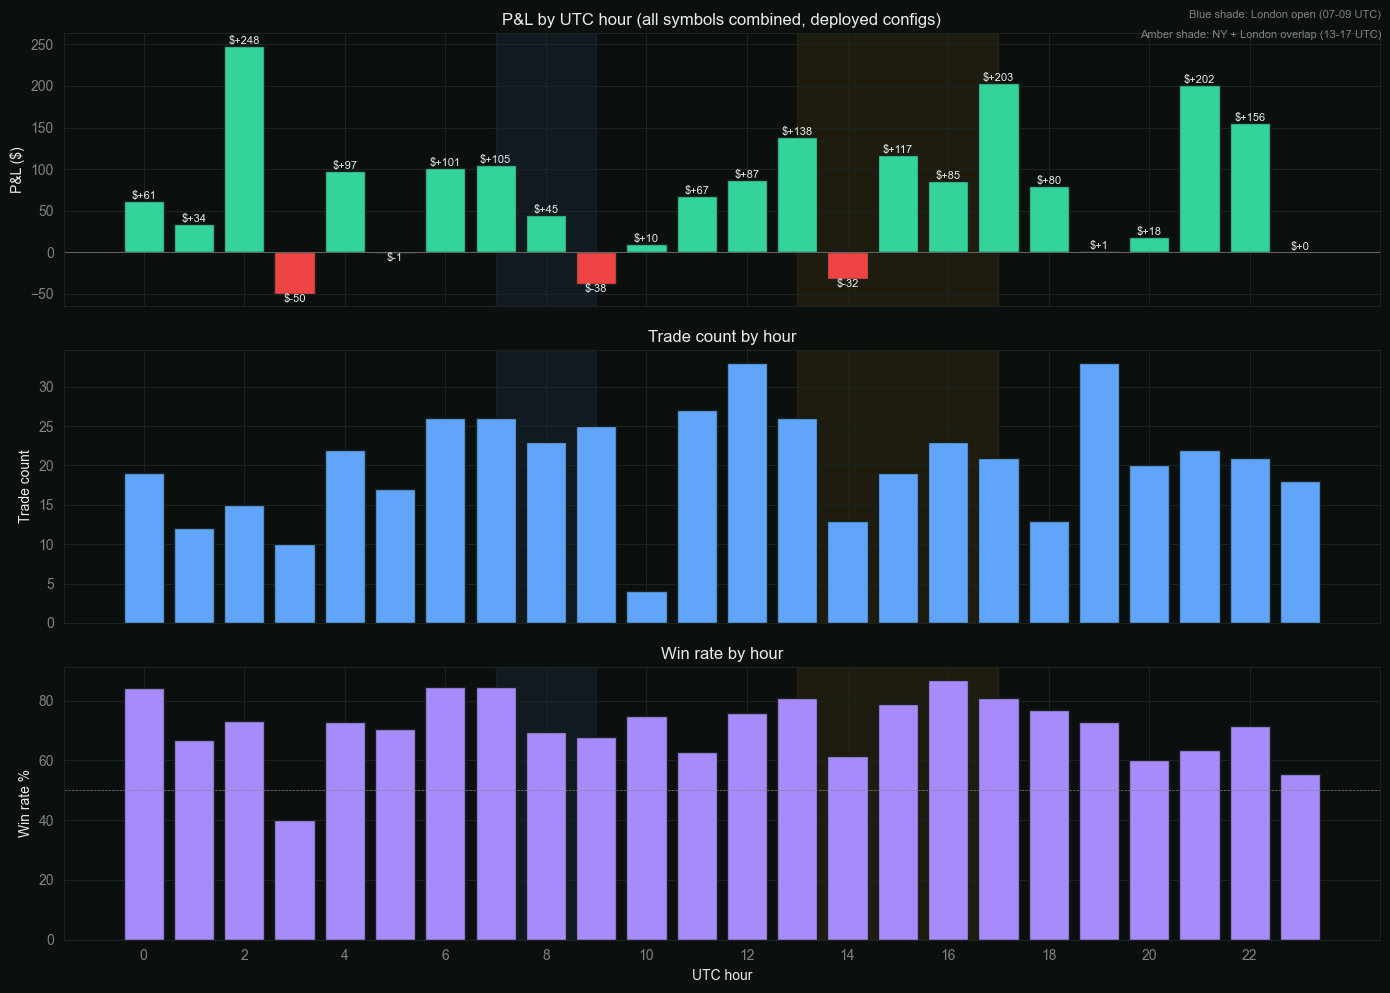

In [6]:
# P&L by UTC hour — bars colored green (profit) / red (loss)
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
colors = ['#34d399' if p >= 0 else '#ef4444' for p in by_hour['pnl']]
axes[0].bar(by_hour['hour'], by_hour['pnl'], color=colors, edgecolor='#1b2420')
axes[0].set_ylabel('P&L ($)'); axes[0].set_title('P&L by UTC hour (all symbols combined, deployed configs)')
axes[0].axhline(0, color='#7a8480', linewidth=0.5)
for i, r in by_hour.iterrows():
    axes[0].annotate(f"${r['pnl']:+.0f}", (r['hour'], r['pnl']), ha='center',
                     va='bottom' if r['pnl']>=0 else 'top', fontsize=8, color='#e6eeea')

axes[1].bar(by_hour['hour'], by_hour['n'], color='#60a5fa', edgecolor='#1b2420')
axes[1].set_ylabel('Trade count'); axes[1].set_title('Trade count by hour')

axes[2].bar(by_hour['hour'], by_hour['win_rate'], color='#a78bfa', edgecolor='#1b2420')
axes[2].set_ylabel('Win rate %'); axes[2].set_xlabel('UTC hour')
axes[2].set_title('Win rate by hour')
axes[2].axhline(50, color='#7a8480', linewidth=0.5, linestyle='--')
axes[2].set_xticks(range(0, 24, 2))

# Highlight London+NY overlap 13-17 UTC
for ax in axes:
    ax.axvspan(13, 17, alpha=0.08, color='#fbbf24', zorder=0)
    ax.axvspan(7, 9, alpha=0.08, color='#60a5fa', zorder=0)

fig.text(0.99, 0.98, 'Blue shade: London open (07-09 UTC)', ha='right', color='#7a8480', fontsize=8)
fig.text(0.99, 0.96, 'Amber shade: NY + London overlap (13-17 UTC)', ha='right', color='#7a8480', fontsize=8)
plt.tight_layout(); plt.show()

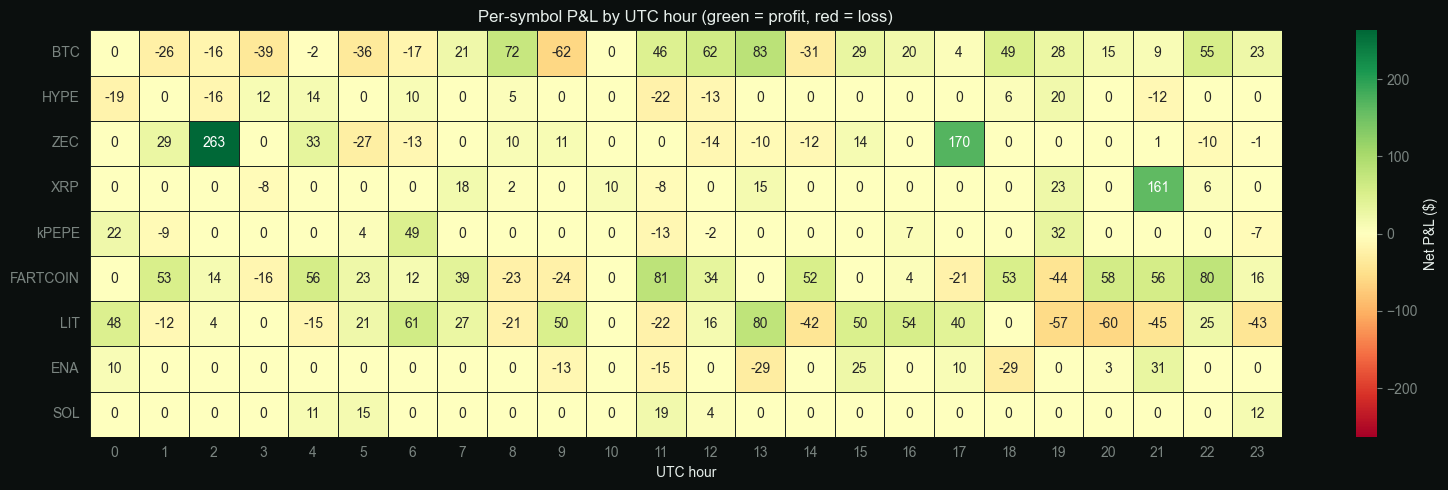

In [7]:
# Per-symbol heatmap — rows=symbol, cols=hour, cells=net P&L
pivot = trades_df.pivot_table(index='symbol', columns='hour', values='pnl', aggfunc='sum', fill_value=0)
pivot = pivot.reindex(index=SYMBOLS, columns=range(24), fill_value=0)

fig, ax = plt.subplots(figsize=(16, 5))
vmax = max(abs(pivot.values.min()), abs(pivot.values.max()))
sns.heatmap(pivot, cmap='RdYlGn', center=0, vmin=-vmax, vmax=vmax,
            annot=True, fmt='.0f', cbar_kws={'label': 'Net P&L ($)'}, ax=ax,
            linewidths=0.5, linecolor='#1b2420')
ax.set_title('Per-symbol P&L by UTC hour (green = profit, red = loss)')
ax.set_xlabel('UTC hour'); ax.set_ylabel('')
plt.tight_layout(); plt.show()

In [8]:
# Identify hot/cold windows per symbol + aggregate
print('=== WORST HOURS overall (net P&L) ===')
print(by_hour[by_hour['n'] > 0].sort_values('pnl').head(5)[['hour','n','pnl','win_rate','pf']].to_string(index=False))
print('\n=== BEST HOURS overall (net P&L) ===')
print(by_hour[by_hour['n'] > 0].sort_values('pnl', ascending=False).head(5)[['hour','n','pnl','win_rate','pf']].to_string(index=False))

print('\n=== Per-symbol worst hour windows (if any stand out) ===')
for sym in SYMBOLS:
    s_trades = trades_df[trades_df['symbol'] == sym]
    if len(s_trades) < 10: continue
    hr_pnl = s_trades.groupby('hour')['pnl'].sum()
    worst_hr = hr_pnl.idxmin(); worst_pnl = hr_pnl.min()
    best_hr = hr_pnl.idxmax(); best_pnl = hr_pnl.max()
    if worst_pnl < -20 or best_pnl > 50:
        print(f'  {sym:<10} best hour {best_hr:>2}h → ${best_pnl:+.0f}  |  worst hour {worst_hr:>2}h → ${worst_pnl:+.0f}')

=== WORST HOURS overall (net P&L) ===
 hour  n        pnl  win_rate       pf
    3 10 -50.086984 40.000000 0.337958
    9 25 -38.416610 68.000000 0.698092
   14 13 -31.756965 61.538462 0.765259
    5 17  -0.612861 70.588235 0.990652
   23 18   0.392449 55.555556 1.005119

=== BEST HOURS overall (net P&L) ===
 hour  n        pnl  win_rate       pf
    2 15 248.453255 73.333333 4.734650
   17 21 203.394545 80.952381 4.620719
   21 22 201.664477 63.636364 2.965340
   22 21 156.012334 71.428571 4.721115
   13 26 138.190852 80.769231 3.685823

=== Per-symbol worst hour windows (if any stand out) ===
  BTC        best hour 13h → $+83  |  worst hour  9h → $-62
  HYPE       best hour 19h → $+20  |  worst hour 11h → $-22
  ZEC        best hour  2h → $+263  |  worst hour  5h → $-27
  XRP        best hour 21h → $+161  |  worst hour 11h → $-8
  FARTCOIN   best hour 11h → $+81  |  worst hour 19h → $-44
  LIT        best hour 13h → $+80  |  worst hour 20h → $-60
  ENA        best hour 21h → $+31  | 

## Experiment 2 — Volume spike filter

Compare: same configs, but only take entries where the bar's `volume / 20-bar-avg-volume` is above various thresholds.

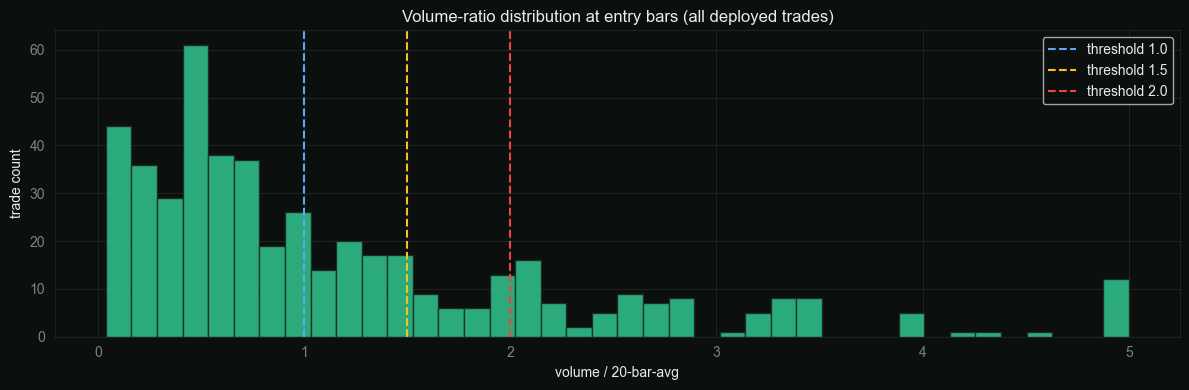


Quantiles of entry vol_ratio:
count    488.00
mean       1.25
std        1.34
min        0.04
25%        0.44
50%        0.77
75%        1.63
90%        2.78
95%        3.42
max       13.97
Name: vol_ratio, dtype: float64


In [9]:
# Distribution of vol_ratio at entries — see how strict different thresholds would be
fig, ax = plt.subplots(figsize=(12, 4))
vr_clip = trades_df['vol_ratio'].clip(upper=5)
ax.hist(vr_clip, bins=40, color='#34d399', edgecolor='#1b2420', alpha=0.8)
for thr, c in [(1.0, '#60a5fa'), (1.5, '#fbbf24'), (2.0, '#ef4444')]:
    ax.axvline(thr, color=c, linestyle='--', label=f'threshold {thr}')
ax.legend(); ax.set_xlabel('volume / 20-bar-avg'); ax.set_ylabel('trade count')
ax.set_title('Volume-ratio distribution at entry bars (all deployed trades)')
plt.tight_layout(); plt.show()

print('\nQuantiles of entry vol_ratio:')
print(trades_df['vol_ratio'].describe(percentiles=[.25, .5, .75, .9, .95]).round(2))

In [10]:
# Re-run backtest with volume filter at multiple thresholds
thresholds = [0.0, 1.0, 1.25, 1.5, 1.75, 2.0]
rows = []
for thr in thresholds:
    total_trades = 0; total_pnl = 0.0; total_wins = 0
    for sym in SYMBOLS:
        fn = f'whale_{sym.replace(":","_")}.json'
        d = json.load(open(os.path.join(DEPLOY_DIR, fn)))
        cfg_d = Cfg(
            trend_filter=d['trend_filter'], entry_type=d['entry_type'],
            rsi_oversold=d['rsi_oversold'], rsi_overbought=d['rsi_overbought'],
            sl_atr=d['sl_atr'], tp1_atr=d['tp1_atr'], tp1_pct=d['tp1_pct'],
            trail_atr=d['trail_atr'], max_hold_bars=d['max_hold_bars'],
            direction=d['direction'], use_1h_filter=d['use_1h_filter'],
            trend_filter_1h=d.get('trend_filter_1h', 'ema_cross'),
            require_4h_agreement=bool(d.get('require_4h_agreement', False)),
            require_btc_1h_confirm=bool(d.get('require_btc_1h_confirm', False)),
            tp2_atr=float(d.get('tp2_atr', 0.0)), tp2_pct=float(d.get('tp2_pct', 0.0)),
            tp3_atr=float(d.get('tp3_atr', 0.0)), tp3_pct=float(d.get('tp3_pct', 0.0)),
        )
        df5 = add_features(fetch_hl(sym, '5m', 10000))
        df1h = add_features(fetch_hl(sym, '1h', 2000))
        df4h = add_features(fetch_hl(sym, '4h', 1000))
        if len(df5) < 250: continue
        arr = precompute(df5, df1h, df4h, build_btc_confirm(df5, df1h_btc))
        eff_lev = HL_CAP[sym] * 0.15
        trades = backtest(arr, cfg_d, leverage=eff_lev,
                          require_btc_confirm=cfg_d.require_btc_1h_confirm,
                          min_vol_ratio=thr)
        total_trades += len(trades)
        total_pnl += sum(t['pnl'] for t in trades)
        total_wins += sum(1 for t in trades if t['pnl'] > 0)
    wr = (total_wins / total_trades * 100) if total_trades else 0
    rows.append({'vol_thr': thr, 'trades': total_trades, 'total_pnl': total_pnl, 'win_rate': wr})
vol_df = pd.DataFrame(rows)
vol_df

,vol_thr,trades,total_pnl,win_rate
0,0.00,488,1736.970493,72.745902
1,1.00,281,1029.810309,73.665480
2,1.25,261,757.739006,72.413793
3,1.50,212,751.885495,72.641509
4,1.75,195,786.153770,73.846154
5,2.00,177,583.992768,71.186441


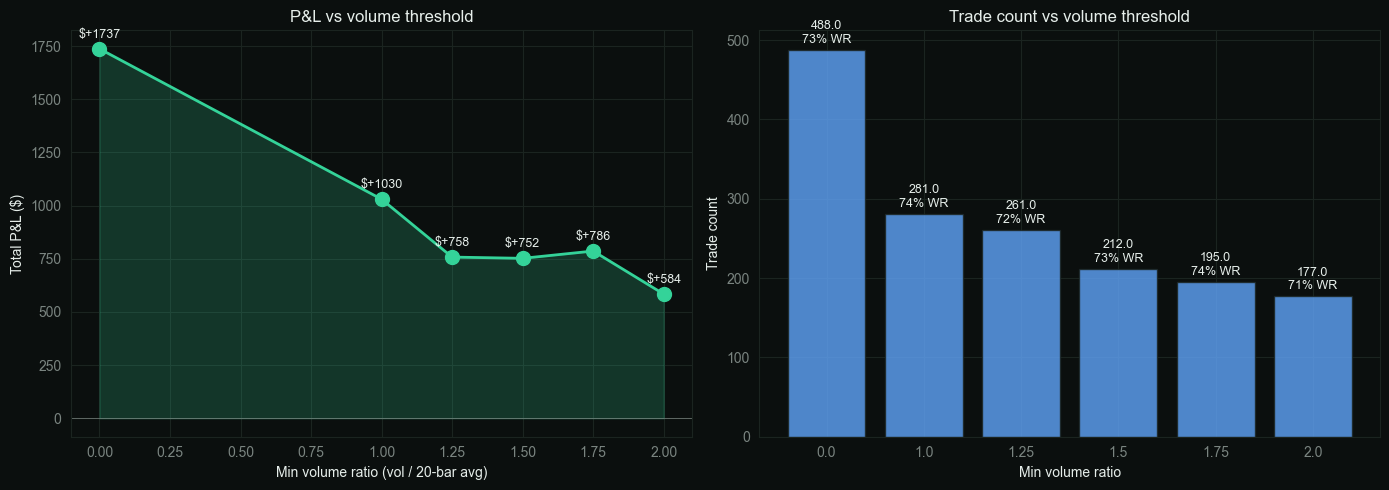


→ Best threshold: 0.0 (P&L $+1737, 488 trades, WR 72.7%)


In [11]:
# Plot volume threshold sweep
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(vol_df['vol_thr'], vol_df['total_pnl'], 'o-', color='#34d399', linewidth=2, markersize=10)
ax1.fill_between(vol_df['vol_thr'], 0, vol_df['total_pnl'], alpha=0.2, color='#34d399')
ax1.axhline(0, color='#7a8480', linewidth=0.5)
ax1.set_xlabel('Min volume ratio (vol / 20-bar avg)')
ax1.set_ylabel('Total P&L ($)')
ax1.set_title('P&L vs volume threshold')
for _, r in vol_df.iterrows():
    ax1.annotate(f"${r['total_pnl']:+.0f}", (r['vol_thr'], r['total_pnl']),
                 textcoords='offset points', xytext=(0,8), ha='center', fontsize=9)

ax2.bar(vol_df['vol_thr'].astype(str), vol_df['trades'], color='#60a5fa', edgecolor='#1b2420', alpha=0.8)
ax2.set_xlabel('Min volume ratio')
ax2.set_ylabel('Trade count')
ax2.set_title('Trade count vs volume threshold')
for i, r in vol_df.iterrows():
    ax2.annotate(f"{r['trades']}\n{r['win_rate']:.0f}% WR", (i, r['trades']),
                 textcoords='offset points', xytext=(0,5), ha='center', fontsize=9)

plt.tight_layout(); plt.show()

best = vol_df.loc[vol_df['total_pnl'].idxmax()]
print(f'\n→ Best threshold: {best["vol_thr"]} (P&L ${best["total_pnl"]:+.0f}, {int(best["trades"])} trades, WR {best["win_rate"]:.1f}%)')

## Verdict + recommendations

Read the cells above and decide:

- **Hour filter:** if the heatmap shows 2-3 hours with consistent negative P&L across multiple symbols, add a blackout window.
- **Volume filter:** if `vol_thr ≥ 1.5` keeps >60% of trades and lifts total P&L, worth deploying as a universal filter.

No changes written to config/deployed — review the numbers, then ask Claude to wire in whichever one survives.